# Ergänzung zu Termin 2: CNNs und Transfer Learning

In Aufgabe 1 sollen Sie Katzen- und Hundebilder klassifizieren, einmal mit einem eigenen CNN,
einmal mit vortrainierten Netzen wie VGG, ResNet und einem Vision Transformer, und die
Ergebnisse miteinander vergleichen. Kapitel 3 und 4 legen dafür die Grundlagen: Convolutions,
Pooling, und wie man ein vortrainiertes Netz für eine neue Aufgabe umbaut. Hier gehen wir diese
Grundlagen in der Reihenfolge durch, in der Sie sie für die Aufgabe brauchen: von den
Bilddaten über die eigene Architektur bis zum fertig trainierten und ausgewerteten Modell.

## 0. Setup

In [1]:
try:
    import torch, torchvision
    print(f"PyTorch {torch.__version__} und torchvision {torchvision.__version__} bereits vorhanden, kein Neuinstall noetig.")
except ImportError:
    !pip install -q torch torchvision

!pip install -q ipywidgets==8.1.9 matplotlib==3.11.2 tqdm==4.70.1

PyTorch 2.4.0+cu124 und torchvision 0.19.0+cu124 bereits vorhanden, kein Neuinstall noetig.


## 1. Bilddaten mit `ImageFolder` und `DataLoader`

Bevor überhaupt ein CNN gebaut werden kann, müssen die Katzen- und Hundebilder als
einheitlich geformte Batches vorliegen. Anders als bei den bisherigen Datensätzen liegen sie
als einzelne Dateien in Ordnern vor, nicht als vorbereiteter Tensor.
`torchvision.datasets.ImageFolder` übernimmt das Einlesen, sofern die Bilder je Klasse in
einem eigenen Unterordner liegen (`Data/katze/...`, `Data/hund/...`). Die Ordnernamen werden
dabei automatisch zu den Klassenlabels.

In [2]:
import os
import random
import tempfile

from PIL import Image


def _synthetische_bilddaten(basis_pfad, groessen):
    for klasse in ("katze", "hund"):
        ordner = os.path.join(basis_pfad, klasse)
        os.makedirs(ordner, exist_ok=True)
        for i, groesse in enumerate(groessen):
            farbwert = random.randint(0, 255)
            bild = Image.new("RGB", groesse, color=(farbwert, farbwert, farbwert))
            bild.save(os.path.join(ordner, f"{i}.png"))


basis_pfad = tempfile.mkdtemp()
_synthetische_bilddaten(basis_pfad, groessen=[(64, 64), (96, 48), (50, 80)])

Die Bilder liegen absichtlich in unterschiedlichen Auflösungen vor, wie es bei einem
selbst zusammengestellten Datensatz üblich ist. Liest man sie ohne Größenanpassung ein:

In [3]:
import torch
from torchvision import datasets, transforms

ohne_resize = datasets.ImageFolder(basis_pfad, transform=transforms.ToTensor())
print(ohne_resize.class_to_idx)

lader = torch.utils.data.DataLoader(ohne_resize, batch_size=3)
try:
    next(iter(lader))
except RuntimeError as fehler:
    print(fehler)

{'hund': 0, 'katze': 1}
stack expects each tensor to be equal size, but got [3, 64, 64] at entry 0 and [3, 48, 96] at entry 1


Der `DataLoader` staut die Tensoren eines Batches per `torch.stack` zusammen. Das setzt
voraus, dass alle Bilder eines Batches dieselbe Form haben. Die Transform-Pipeline braucht
deshalb neben `ToTensor()` immer auch eine feste Zielgröße:

In [4]:
transform = transforms.Compose([
    transforms.Resize((64, 64)),
    transforms.ToTensor(),
])
demo_set = datasets.ImageFolder(basis_pfad, transform=transform)
demo_loader = torch.utils.data.DataLoader(demo_set, shuffle=True, batch_size=3, num_workers=0)

bilder, labels = next(iter(demo_loader))
print(bilder.shape, labels)

torch.Size([3, 3, 64, 64]) tensor([1, 1, 0])


Jetzt liefert ein Batch einen einzigen Tensor der Form `(batch_size, 3, 64, 64)` statt
einzelner Bilder unterschiedlicher Größe. Genau dieses Muster, `ImageFolder` mit `Resize`
und `ToTensor`, anschließend ein `DataLoader` mit `shuffle` und `batch_size`, setzt Aufgabe 1
für `train_set`/`valid_set` und `train_loader`/`valid_loader` um.

## 2. Das eigene CNN: `Conv2d`, Pooling und `view`

Mit passend geformten Bild-Batches aus Abschnitt 1 geht es jetzt um die Architektur selbst.
Für das eigene CNN sind mindestens vier bis fünf `Conv2d`-Schichten gefordert, gefolgt von
einer oder mehreren linearen Schichten. Damit die Eingabegröße der ersten linearen Schicht
stimmt, muss man wissen, wie sich die räumliche Auflösung durch Convolution und Pooling
verändert.

In [5]:
def conv_ausgabegroesse(eingabegroesse, kernel_size, stride, padding):
    return (eingabegroesse + 2 * padding - kernel_size) // stride + 1


print(conv_ausgabegroesse(eingabegroesse=64, kernel_size=3, stride=1, padding=1))

64


Mit dem Regler lässt sich das für beliebige Kombinationen durchspielen. `eingabegroesse`
bezeichnet dabei die Breite bzw. Höhe der Eingabe (nicht die Batch- oder Kanaldimension);
`kernel_size`, `stride` und `padding` sind dieselben Bezeichner wie im `nn.Conv2d`-Konstruktor.

In [6]:
import ipywidgets as widgets
from IPython.display import clear_output


def zeige_ausgabegroesse(eingabegroesse, kernel_size, stride, padding):
    clear_output(wait=True)
    print(conv_ausgabegroesse(eingabegroesse, kernel_size, stride, padding))


widgets.interact(
    zeige_ausgabegroesse,
    eingabegroesse=widgets.IntSlider(min=1, max=256, value=64, description="eingabegroesse"),
    kernel_size=widgets.IntSlider(min=1, max=11, value=3, description="kernel_size"),
    stride=widgets.IntSlider(min=1, max=4, value=1, description="stride"),
    padding=widgets.IntSlider(min=0, max=5, value=1, description="padding"),
)

interactive(children=(IntSlider(value=64, description='eingabegroesse', max=256, min=1), IntSlider(value=3, de…

<function __main__.zeige_ausgabegroesse(eingabegroesse, kernel_size, stride, padding)>

Bei `kernel_size=3`, `stride=1` und `padding=1` bleibt die Ausgabegröße gleich der
Eingabegröße. Das ist eine in CNN-Architekturen häufig genutzte Voreinstellung. Größerer `stride`
oder `kernel_size` verkleinert die Ausgabe, größeres `padding` wirkt dem entgegen.

Pooling-Schichten verkleinern die Auflösung zusätzlich, ohne eigene lernbare Parameter:

In [7]:
import torch.nn as nn

merkmalskarte = torch.rand(1, 4, 8, 8)
pooling = nn.MaxPool2d(kernel_size=2, stride=2)
print(pooling(merkmalskarte).shape)

torch.Size([1, 4, 4, 4])


`MaxPool2d(kernel_size=2, stride=2)` halbiert Höhe und Breite, die Kanalzahl bleibt
unverändert. Nach den `Conv2d`- und Pooling-Schichten muss die Merkmalskarte auf eine
lineare Schicht umgelegt werden:

In [8]:
demo_batch = torch.rand(5, 16, 4, 4)  # (batch_size, channels, height, width)
flach = demo_batch.view(demo_batch.size(0), -1)
print(flach.shape)

torch.Size([5, 256])


`demo_batch.view(demo_batch.size(0), -1)` hält die Batch-Dimension explizit fest und
fasst den Rest zusammen. Wird stattdessen die Batch-Größe fest eingetragen
(`view(64, -1)` statt `view(x.size(0), -1)`), bricht das genau bei der letzten Batch eines
Epoch-Durchlaufs, sobald die Datensatzgröße kein Vielfaches von `batch_size` ist. Die Anzahl
der `in_features` der anschließenden `nn.Linear`-Schicht ergibt sich aus Kanalzahl, Höhe und
Breite der letzten Merkmalskarte: Kanalzahl mal Höhe mal Breite.

## 3. `log_softmax` mit `NLLLoss` versus Logits mit `CrossEntropyLoss`

Am Ende der in Abschnitt 2 zusammengesetzten Schichtfolge steht eine Aktivierung auf der
Ausgabe, und die entscheidet mit, welche Verlustfunktion überhaupt passt. Der CNN-Stub aus
Aufgabe 1 endet mit `F.log_softmax(x)`, nicht mit rohen Logits wie das Klassifikationsnetz
aus Termin 1. Das hat unmittelbare Folgen für die Wahl der Verlustfunktion.

In [9]:
import torch.nn.functional as F

logits = torch.tensor([[2.0, 0.5, -1.0]])
log_wahrscheinlichkeiten = F.log_softmax(logits, dim=1)
ziel = torch.tensor([0])

print(F.nll_loss(log_wahrscheinlichkeiten, ziel).item())
print(F.cross_entropy(logits, ziel).item())

0.24131132662296295
0.24131132662296295


Beide Zeilen liefern denselben Wert. `NLLLoss` erwartet bereits Log-Wahrscheinlichkeiten als
Eingabe, deshalb steht `log_softmax` in der `forward`-Methode des eigenen CNN.
`CrossEntropyLoss` wendet Softmax und Logarithmus intern selbst an und erwartet rohe Logits;
genau diese Kombination nutzte das Klassifikationsnetz aus Termin 1, ohne Aktivierung am
Ausgang. Kombiniert man `log_softmax` in `forward()` mit `CrossEntropyLoss`, wird Softmax
zweimal angewendet, was Gradienten und Ergebnis verfälscht. Zur `forward`-Methode aus
Aufgabe 1 passt also `NLLLoss`.

## 4. Den Kopf eines vortrainierten Netzes finden und ersetzen

Damit ist die Architektur und Verlustfunktion des eigenen CNN vollständig festgelegt.
Aufgabe 1 verlangt daneben aber auch den Einsatz dreier vortrainierter Architekturen: VGG,
ResNet und ein Vision Transformer. "Vortrainiert" heißt: Diese Netze wurden bereits auf
ImageNet trainiert, einem Datensatz mit über einer Million Bildern aus 1.000 Kategorien.
Dabei haben ihre Schichten bereits gelernt, allgemeine visuelle Muster wie Kanten, Texturen
und Formen zu erkennen. Das sind Merkmale, die für die meisten Bildklassifikationsaufgaben
nützlich sind, nicht nur für die ursprünglichen 1.000 Klassen. Genau darin liegt der Vorteil
gegenüber dem eigenen CNN aus den Abschnitten 2 und 3: Bei einem vergleichsweise kleinen
Datensatz wie Katzen/Hunde reicht die Datenmenge oft nicht aus, um solche Merkmale von
Grund auf selbst zu lernen, ein vortrainiertes Netz bringt sie bereits mit. Angepasst werden
muss dann nur noch der letzte Teil: Die letzte Schicht dieser Netze ist auf genau 1.000
ImageNet-Klassen ausgelegt und muss auf die beiden Klassen Katze/Hund umgestellt werden.

In [10]:
from torchvision import models

vgg = models.vgg16(weights=None)
resnet = models.resnet18(weights=None)
vit = models.vit_b_16(weights=None)

print(vgg.classifier[-1])
print(resnet.fc)
print(vit.heads[-1])

Linear(in_features=4096, out_features=1000, bias=True)
Linear(in_features=512, out_features=1000, bias=True)
Linear(in_features=768, out_features=1000, bias=True)


Jede Architektur benennt ihre letzte Schicht anders: bei ResNet heißt das Attribut `fc`, bei
VGG ist es der letzte Eintrag im `classifier`-Sequential, beim Vision Transformer der letzte
Eintrag in `heads`. Das Vorgehen für ResNet und VGG steht so im Buch; auf den Vision
Transformer lässt es sich unmittelbar übertragen, sobald die Struktur einmal ausgegeben
wurde: letzte lineare Schicht identifizieren, durch ein neues `nn.Linear` mit passender
Klassenzahl ersetzen.

In [11]:
n_classes = 2
vgg.classifier[-1] = nn.Linear(vgg.classifier[-1].in_features, n_classes)
resnet.fc = nn.Linear(resnet.fc.in_features, n_classes)
vit.heads[-1] = nn.Linear(vit.heads[-1].in_features, n_classes)

print(vgg.classifier[-1], resnet.fc, vit.heads[-1])

Linear(in_features=4096, out_features=2, bias=True) Linear(in_features=512, out_features=2, bias=True) Linear(in_features=768, out_features=2, bias=True)


`in_features` der bisherigen letzten Schicht wird hier direkt übernommen, statt die Zahl
(4096, 512, 768) hart einzutragen. Das bleibt auch dann korrekt, wenn eine andere VGG- oder
ResNet-Variante gewählt wird.

Zur eigentlichen Transfer-Learning-Idee gehört meist noch ein zweiter Schritt: die bereits
gelernten Merkmale einfrieren, damit nur der neue Kopf trainiert wird.

In [12]:
for parameter in vgg.features.parameters():
    parameter.requires_grad_(False)

Eine frisch angelegte `nn.Linear`-Schicht hat `requires_grad=True` standardmäßig und bleibt
trainierbar, auch wenn der Rest des Netzes eingefroren ist. Bei einem vergleichsweise kleinen
Datensatz wie Katzen/Hunde verkürzt das eingefrorene Feature-Netz die Trainingszeit spürbar,
da für diese Schichten keine Gradienten berechnet werden müssen.

## 5. Trainings- und Validierungsphase: `train()`/`eval()` und `torch.no_grad()`

Aufgabe 1 verlangt kein einzelnes Modell, sondern einen Vergleich von vier Modelltypen: dem
eigenen, von Grund auf trainierten CNN aus den Abschnitten 2 und 3, sowie den drei in
Abschnitt 4 angepassten vortrainierten Architekturen VGG, ResNet und Vision Transformer. Der
Sinn dieses Vergleichs: zeigen, ob ein kleines, selbst entworfenes Netz mit etablierten,
vortrainierten Architekturen mithalten kann. `vgg`, `resnet` und `vit` stehen aus Abschnitt 4
bereits als fertige Modell-Objekte bereit; das eigene CNN wird erst in Abschnitt 6
tatsächlich instanziiert, folgt dabei aber derselben Trainingslogik. Alle vier durchlaufen
dafür dieselbe Trainingsfunktion aus Aufgabe 1, die pro Epoche zwei Phasen abarbeitet:
Training über `train_loader`, Validierung über `valid_loader`. Für Schichten wie `Dropout`,
die im VGG-Klassifikator und häufig auch im eigenen CNN vorkommen, macht das einen
Unterschied.

`Dropout` dient als Schutz gegen Überanpassung: Zufälliges Abschalten von Neuronen im
Training verhindert, dass sich das Netz auf feste Kombinationen einzelner Neuronen
verlässt, und zwingt es, robustere, redundante Merkmale zu lernen, die auch auf ungesehenen
Daten funktionieren. Gerade bei einem kleinen Datensatz wie Katzen/Hunde ist das ein
wichtiger Hebel gegen bloßes Auswendiglernen der Trainingsbilder.

In [13]:
torch.manual_seed(0)
dropout = nn.Dropout(p=0.5)
x = torch.ones(1, 10)

dropout.train()
print(dropout(x))

dropout.eval()
print(dropout(x))

tensor([[2., 0., 0., 2., 2., 0., 0., 2., 2., 2.]])
tensor([[1., 1., 1., 1., 1., 1., 1., 1., 1., 1.]])


Im Trainingsmodus setzt `Dropout` zufällig Werte auf 0, im Eval-Modus ist die Schicht
wirkungslos und reicht die Eingabe unverändert durch. Für die Validierung soll ja die
tatsächliche Vorhersagequalität des vollständigen Netzes gemessen werden, nicht die eines
künstlich ausgedünnten. `model.train()` und `model.eval()` schalten dieses Verhalten für
alle Teilschichten eines Modells gemeinsam um. Vor der Trainingsphase steht deshalb
`model.train()`, vor der Validierungsphase `model.eval()`.

In [14]:
schicht = nn.Linear(3, 1)
eingabe = torch.rand(1, 3)

normal = schicht(eingabe)
print(normal.requires_grad)

with torch.no_grad():
    ohne_graph = schicht(eingabe)
print(ohne_graph.requires_grad)

True
False


Gradienten dienen nur einem Zweck: der Parameteraktualisierung durch `optimizer.step()`.
Genau dieser Schritt fehlt in der Validierung. Das Netz wird dort nur ausgewertet, nicht
verändert, also gibt es auch nichts, das rückwärts differenziert werden müsste. Weil die
Gradienten ohnehin nie gebraucht würden, lohnt sich ihre Berechnung nicht: `torch.no_grad()`
verhindert, dass PyTorch dafür unnötig den Berechnungsgraphen aufbaut, was Rechenzeit und
Speicher spart. Genau in diesem Kontext steht in Aufgabe 1 die Validierungsschleife über
`valid_loader`.

## 6. Alles zusammen: das eigene CNN trainieren und auswerten

Wie im Praktikum versuchen wir, Bilder zwei Klassen zuzuordnen, nur eben orange und blau
eingefärbte Flächen statt Katzen und Hunde. Die Bausteine aus den Abschnitten 1 bis 5 lassen
sich jetzt zu einem vollständigen, wenn auch kleinen Durchlauf zusammensetzen: passend
geladene Bildbatches, eine `Conv2d`/Pooling-Architektur mit `log_softmax`-Ausgang, `NLLLoss`
als Verlustfunktion, das in Abschnitt 4 vorbereitete `resnet` als Vergleichsmodell und
`train()`/`eval()` für Trainings- bzw. Validierungsphase.
Ziel ist, aus einem 32×32-Bild vorherzusagen, ob es eine Katze oder ein Hund zeigt. Damit
sich das ohne den echten, mehrere hundert Megabyte großen Datensatz nachvollziehen lässt,
stehen auch hier synthetische Bilder stellvertretend für die echten Fotos, anders als in
Abschnitt 1 aber mit einem tatsächlich lernbaren Unterschied zwischen den Klassen:
Katzenbilder sind orange, Hundebilder blau eingefärbt, jeweils mit etwas Farbrauschen.

In [15]:
import matplotlib.pyplot as plt


def _lernbare_bilddaten(basis_pfad, anzahl_pro_klasse):
    random.seed(0)
    grundfarben = {"katze": (200, 60, 60), "hund": (60, 60, 200)}
    for klasse, grundfarbe in grundfarben.items():
        ordner = os.path.join(basis_pfad, klasse)
        os.makedirs(ordner, exist_ok=True)
        for i in range(anzahl_pro_klasse):
            rauschen = [random.randint(-40, 40) for _ in range(3)]
            farbe = tuple(max(0, min(255, kanal + wert)) for kanal, wert in zip(grundfarbe, rauschen))
            bild = Image.new("RGB", (32, 32), color=farbe)
            bild.save(os.path.join(ordner, f"{i}.png"))


train_pfad = tempfile.mkdtemp()
valid_pfad = tempfile.mkdtemp()
_lernbare_bilddaten(train_pfad, anzahl_pro_klasse=24)
_lernbare_bilddaten(valid_pfad, anzahl_pro_klasse=6)

bildtransform = transforms.Compose([transforms.Resize((32, 32)), transforms.ToTensor()])
train_set = datasets.ImageFolder(train_pfad, transform=bildtransform)
valid_set = datasets.ImageFolder(valid_pfad, transform=bildtransform)
train_loader = torch.utils.data.DataLoader(train_set, shuffle=True, batch_size=8)
valid_loader = torch.utils.data.DataLoader(valid_set, batch_size=8)

`train_set`/`valid_set` und `train_loader`/`valid_loader` heißen bewusst genauso wie in
Aufgabe 1. Bevor es an die Architektur geht, lohnt sich, genau wie im Buch empfohlen, ein
Blick auf die geladenen Tensoren selbst, mit derselben `imshow`-Funktion, die auch Aufgabe 1
für die echten Katzen-/Hundebilder verwendet:

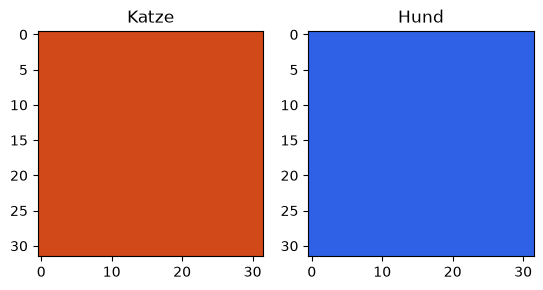

In [16]:
import numpy as np


def imshow(inp):
    inp = inp.numpy().transpose((1, 2, 0))
    inp = np.clip(inp, 0, 1)
    plt.imshow(inp)


katze_index = train_set.targets.index(train_set.class_to_idx["katze"])
hund_index = train_set.targets.index(train_set.class_to_idx["hund"])

plt.subplot(1, 2, 1)
imshow(train_set[katze_index][0])
plt.title("Katze")
plt.subplot(1, 2, 2)
imshow(train_set[hund_index][0])
plt.title("Hund")
plt.show()

Der Farbunterschied zwischen den beiden Klassen ist genau das Muster, das die Netze im
Training erkennen lernen sollen. Bei den echten Fotos ist die Aufgabe ungleich schwerer, da
dort nicht die Farbe, sondern Form und Textur über die Klasse entscheiden.

Die eigene Architektur hält sich an die in Aufgabe 1 geforderten vier `Conv2d`-Schichten,
abwechselnd mit Pooling, bis die 32×32-Eingabe auf 4×4 geschrumpft ist:

In [17]:
class EigenesCNN(nn.Module):
    def __init__(self, n_classes):
        super().__init__()
        self.conv1 = nn.Conv2d(3, 8, kernel_size=3, stride=1, padding=1)
        self.conv2 = nn.Conv2d(8, 16, kernel_size=3, stride=1, padding=1)
        self.conv3 = nn.Conv2d(16, 32, kernel_size=3, stride=1, padding=1)
        self.conv4 = nn.Conv2d(32, 64, kernel_size=3, stride=1, padding=1)
        self.pool = nn.MaxPool2d(kernel_size=2, stride=2)
        self.fc = nn.Linear(64 * 4 * 4, n_classes)

    def forward(self, x):
        x = self.pool(F.relu(self.conv1(x)))  # 32 -> 16
        x = self.pool(F.relu(self.conv2(x)))  # 16 -> 8
        x = self.pool(F.relu(self.conv3(x)))  # 8 -> 4
        x = F.relu(self.conv4(x))  # bleibt 4x4, kein weiteres Pooling
        x = x.view(x.size(0), -1)  # Batch-Dimension erhalten, Rest flach
        return F.log_softmax(self.fc(x), dim=1)

Damit sich das eigene CNN tatsächlich mit einer der vortrainierten Architekturen aus
Abschnitt 4 vergleichen lässt, braucht es, wie in Aufgabe 1 selbst vorgeschlagen, eine
wiederverwendbare Trainingsfunktion, die für beliebige Modelle funktioniert. Die
Verlustfunktion ist dabei bewusst ein Parameter und kein fester Bestandteil der Funktion:
Sie muss zur `forward()`-Ausgabe des jeweiligen Modells passen (Abschnitt 3). Das eigene CNN
endet mit `log_softmax` und braucht `NLLLoss`; die unveränderte `forward()`-Methode von VGG,
ResNet und Vision Transformer liefert dagegen rohe Logits und braucht `CrossEntropyLoss`.

In [18]:
def train_model(model, loss_fn, epochs=15, learning_rate=1e-3):
    optimizer = torch.optim.Adam(model.parameters(), lr=learning_rate)
    verlauf = []
    for _ in range(epochs):
        model.train()
        for bilder, labels in train_loader:
            optimizer.zero_grad()
            verlust = loss_fn(model(bilder), labels)
            verlust.backward()
            optimizer.step()
        verlauf.append(verlust.item())
    return verlauf


def evaluate_model(model, loader):
    model.eval()
    richtige, gesamt = 0, 0
    with torch.no_grad():
        for bilder, labels in loader:
            vorhersagen = model(bilder).argmax(dim=1)
            richtige += (vorhersagen == labels).sum().item()
            gesamt += labels.size(0)
    return richtige / gesamt

Mit derselben Funktion lassen sich jetzt das eigene CNN und, als Vertreter der
vortrainierten Architekturen, das in Abschnitt 4 vorbereitete `resnet` trainieren:

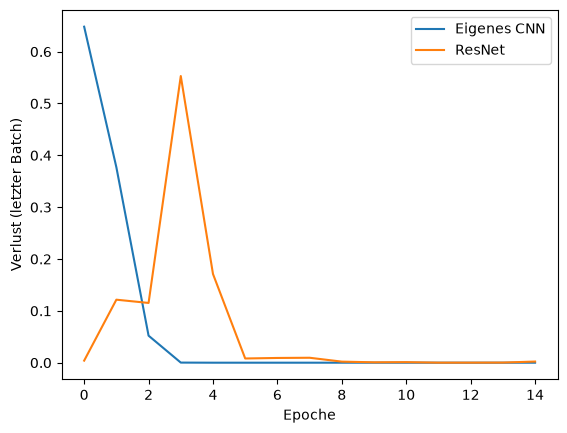

Genauigkeit eigenes CNN: 100.0%
Genauigkeit ResNet:      100.0%


In [19]:
cnn = EigenesCNN(n_classes=2)
verlauf_cnn = train_model(cnn, loss_fn=nn.NLLLoss())
genauigkeit_cnn = evaluate_model(cnn, valid_loader)

verlauf_resnet = train_model(resnet, loss_fn=nn.CrossEntropyLoss())
genauigkeit_resnet = evaluate_model(resnet, valid_loader)

plt.plot(verlauf_cnn, label="Eigenes CNN")
plt.plot(verlauf_resnet, label="ResNet")
plt.xlabel("Epoche")
plt.ylabel("Verlust (letzter Batch)")
plt.legend()
plt.show()

print(f"Genauigkeit eigenes CNN: {genauigkeit_cnn:.1%}")
print(f"Genauigkeit ResNet:      {genauigkeit_resnet:.1%}")

Beide Verlustkurven fallen, und `evaluate_model` liefert für beide eine Genauigkeit auf
`valid_loader`. Der eigentliche Vergleich aus Aufgabe 1 ist damit nichts anderes als das
Nebeneinanderstellen dieser beiden Zahlen. `train_model(vgg, loss_fn=nn.CrossEntropyLoss())`
funktioniert mit exakt demselben Aufruf und wurde hier aus Zeit- und Rechengründen nicht
ausgeführt, da VGG deutlich mehr Parameter hat als das eigene CNN oder ResNet18. Beim Vision
Transformer kommt ein zweiter Grund hinzu: `vit_b_16` erwartet fest 224×224 Pixel große
Eingaben, weil die Positions-Embeddings genau auf diese Anzahl an Bild-Patches ausgelegt
sind. An den hier verwendeten 32×32-Platzhalterbildern würde `vit(bilder)` mit einem
Shape-Fehler abbrechen, nicht nur langsamer laufen. In Aufgabe 1 mit den echten Fotos, die
für jedes Modell auf die jeweils erwartete Größe skaliert werden, tritt dieses Problem nicht
auf. Wichtiger noch: `vgg`, `resnet` und `vit` wurden in Abschnitt 4 bewusst ohne
vortrainierte Gewichte angelegt (`weights=None`), um den langsamen Download zu vermeiden.
Der Vergleich hier zeigt deshalb nur Unterschiede zwischen zufällig initialisierten
Architekturen auf einer trivial trennbaren Farbaufgabe, nicht den eigentlichen
Transfer-Learning-Vorteil. Für den tatsächlichen Vergleich in Aufgabe 1, mit den echten
Fotos und echten vortrainierten Gewichten, ist ein deutlicherer Unterschied zwischen dem
eigenen CNN und den vortrainierten Netzen zu erwarten als hier.

`cnn.eval()`/`resnet.eval()` schalten Dropout- bzw. BatchNorm-Schichten in den
Auswertungsmodus, `torch.no_grad()` spart innerhalb von `evaluate_model` den
Berechnungsgraphen, den die Validierung ohnehin nicht braucht. Das sind exakt die beiden
Punkte aus Abschnitt 5, jetzt im Zusammenspiel.

## 7. Zusammenfassung

- `ImageFolder` liest Bilder klassenweise aus einer Ordnerstruktur; der `DataLoader` braucht
  einheitliche Tensor-Größen, daher vor `ToTensor()` immer ein `Resize`.
- Ausgabegröße einer `Conv2d`-Schicht: `(Eingabegröße + 2·padding − kernel_size) // stride + 1`;
  Pooling verkleinert zusätzlich, ohne eigene Parameter.
- Vorm Flatten die Batch-Dimension explizit mit `x.view(x.size(0), -1)` erhalten, nicht mit
  einer hart eingetragenen Batch-Größe.
- `log_softmax` in `forward()` passt zu `NLLLoss`, rohe Logits passen zu `CrossEntropyLoss`,
  nie mischen.
- Kopf eines vortrainierten Netzes anpassen: Struktur ausgeben, letzte lineare Schicht durch
  ein neues `nn.Linear` ersetzen, Feature-Schichten bei Bedarf einfrieren.
- `model.train()`/`model.eval()` vor Trainings- bzw. Validierungsphase setzen;
  `torch.no_grad()` für die Validierung verwenden.
- Eine wiederverwendbare `train_model`/`evaluate_model`-Funktion mit der Verlustfunktion als
  Parameter erlaubt den direkten Vergleich mehrerer Modelle: hier eigenes CNN gegen ResNet,
  in Aufgabe 1 alle vier Architekturen über denselben Funktionsaufruf.